In [9]:
# @title Imports
import gymnasium as gym
from gymnasium.wrappers import RecordEpisodeStatistics
import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import seaborn as sns
import matplotlib.pyplot as plt



from popy.simulation_tools import *
from popy.io_tools import load_behavior
from popy.behavior_data_tools import *
from popy.plotting.plotting_tools import *

from simulation_helpers import simulate_agent, estimate_ll
from popy.config import COLORS, PROJECT_PATH_LOCAL

In [10]:
"""model_renames = {
    'recording': lambda monkey: monkey,  # This will be handled specially
    #'Repeating agent': 'Repeating agent',
    'WSLS agent (long history)': 'WSLS',
    'Q-Learner': 'Standard RL',
    'Q-Learner counterfactual': 'Inferential RL',
    #'Shift-value agent': 'none',
    'Shift-value agent with reset': 'Foraging'
}


def load_fit_stats_no_sticky():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_results_{monkey}.csv')
        res_temp = pd.read_csv(floc)

        if 'model' in res_temp.columns:
            res_temp = res_temp.rename(columns={'model': 'Model'})

        # add monkey name to the dataframe
        res_temp['monkey'] = monkey

        # rename models, remove those not in the renames dict
        res_temp = res_temp[res_temp['Model'].isin(model_renames.keys())]
        # replace model names according to the renames dict
        res_temp['Model'] = res_temp['Model'].replace(model_renames)

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

def load_fit_stats_sticky():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_results_{monkey}_only_stickyness.csv')
        res_temp = pd.read_csv(floc)

        if 'model' in res_temp.columns:
            res_temp = res_temp.rename(columns={'model': 'Model'})

        # add monkey name to the dataframe
        res_temp['monkey'] = monkey

        # rename models, remove those not in the renames dict
        res_temp = res_temp[res_temp['Model'].isin(model_renames.keys())]
        # replace model names according to the renames dict
        res_temp['Model'] = res_temp['Model'].replace(model_renames)

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

res_no_sticky = load_fit_stats_no_sticky()
res_no_sticky = res_no_sticky.replace({'Model': {'Standard RL': 'Standard RL-s', 'Inferential RL': 'Inferential RL-s'}})

# rename Standard RL and Inferential RL
res_sticky = load_fit_stats_sticky()
res_all = pd.concat([res_no_sticky, res_sticky], axis=0)

# remove Unnamed: 0 column if exists
if 'Unnamed: 0' in res_all.columns:
    res_all = res_all.drop(columns=['Unnamed: 0'])
# place 'stickyness' column after 'beta' column
if 'stickyness' in res_all.columns:
    stickyness_col = res_all.pop('stickyness')
    res_all.insert(5, 'stickyness', stickyness_col)

#sort models by: wsls, standard, inferential, foraging
model_order = ['Repeating agent', 'WSLS', 'Standard RL-s', 'Inferential RL-s', 'Standard RL', 'Inferential RL', 'Foraging']
res_all['Model'] = pd.Categorical(res_all['Model'], categories=model_order, ordered=True)
res_all = res_all.sort_values('Model')

res_all"""

"model_renames = {\n    'recording': lambda monkey: monkey,  # This will be handled specially\n    #'Repeating agent': 'Repeating agent',\n    'WSLS agent (long history)': 'WSLS',\n    'Q-Learner': 'Standard RL',\n    'Q-Learner counterfactual': 'Inferential RL',\n    #'Shift-value agent': 'none',\n    'Shift-value agent with reset': 'Foraging'\n}\n\n\ndef load_fit_stats_no_sticky():\n    # show bic and LPT values\n    dfs = []\n    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:\n        # load behavior data\n        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', f'simulation_results_{monkey}.csv')\n        res_temp = pd.read_csv(floc)\n\n        if 'model' in res_temp.columns:\n            res_temp = res_temp.rename(columns={'model': 'Model'})\n\n        # add monkey name to the dataframe\n        res_temp['monkey'] = monkey\n\n        # rename models, remove those not in the renames dict\n        res_temp = res_temp[res_temp['Model'].isin(mode

In [11]:
def load_res():
    # show bic and LPT values
    dfs = []
    for monkey in ['ka', 'po']:#:, 'yu_sham', 'yu_DCZ']:
        # load behavior data
        floc = os.path.join(PROJECT_PATH_LOCAL, 'notebooks', 'behav_modeling', 'results', 'model_fitting', f'simulation_results_{monkey}.csv')
        res_temp = pd.read_csv(floc)

        # add monkey name to the dataframe and move to first col
        res_temp['monkey'] = monkey
        

        dfs.append(res_temp)
    return pd.concat(dfs, ignore_index=True)

res_all = load_res()
#res_all = res_all.sort_values(['Model', 'monkey'])

res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickyness_bias,b2,abandoned_bias,abandoned_decay,LL_best,BIC_best,LPT_best,Reward rate,Proba best,monkey
0,Repeating agent,0.153286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9431.020881,18872.121721,0.673502,0.40098,0.33165,ka
1,WSLS agent,0.074983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8088.235660,16186.551278,0.712492,0.49627,0.56905,ka
2,Standard RL,NaN,0.546608,NaN,7.578206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9063.468638,18147.097193,0.683957,0.54286,0.70015,ka
3,Standard RL - stickyness,NaN,0.427665,NaN,4.399407,NaN,NaN,NaN,1.556317,NaN,NaN,NaN,-7164.277779,14358.795434,0.740623,0.50925,0.62737,ka
4,Standard RL - forgetting,NaN,0.370367,NaN,11.114967,NaN,0.968191,0.057793,NaN,NaN,NaN,NaN,-5708.888264,11458.096363,0.787205,0.54386,0.71525,ka
5,Standard RL - forgetting + stickyness,NaN,0.484152,NaN,10.187384,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN,-5668.799199,11387.998191,0.788529,0.54582,0.71234,ka
6,Inferential RL,NaN,0.122843,NaN,9.018651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-12829.208355,25678.576627,0.584098,0.54226,0.70288,ka
7,Inferential RL - stickyness,NaN,0.223282,NaN,5.498370,NaN,NaN,NaN,2.641171,NaN,NaN,NaN,-6814.173977,13658.587830,0.751571,0.54978,0.72061,ka
8,Inferential RL - stickyness + spatial bias,NaN,0.402494,NaN,4.186326,NaN,NaN,NaN,3.309617,-0.060499,NaN,NaN,-6769.929213,13580.178260,0.752966,0.53757,0.67889,ka
9,Inferential RL - stickyness + multiple alphas,NaN,0.082412,0.330251,6.570581,NaN,NaN,NaN,2.399904,NaN,NaN,NaN,-6682.038281,13404.396398,0.755745,0.54783,0.71700,ka


In [12]:
# rename Inferential RL - multiple alphas + stickyness to Inferential RL - stickyness + multiple alphas, and move it to before Inferential RL - stickyness + spatial bias
res_all = res_all.replace({'Model': {'Inferential RL - multiple alphas + stickyness': 'Inferential RL - stickyness + multiple alphas'}})
# rename Standard RL - forgetting + stickyness to Standard RL - stickyness + forgetting
res_all = res_all.replace({'Model': {'Standard RL - forgetting + stickyness': 'Standard RL - stickyness + forgetting'}})



res_all

,Model,epsilon,alpha,alpha_unchosen,beta,V0,forgetting_rate,forgetting_threshold,stickyness_bias,b2,abandoned_bias,abandoned_decay,LL_best,BIC_best,LPT_best,Reward rate,Proba best,monkey
0,Repeating agent,0.153286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9431.020881,18872.121721,0.673502,0.40098,0.33165,ka
1,WSLS agent,0.074983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-8088.235660,16186.551278,0.712492,0.49627,0.56905,ka
2,Standard RL,NaN,0.546608,NaN,7.578206,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9063.468638,18147.097193,0.683957,0.54286,0.70015,ka
3,Standard RL - stickyness,NaN,0.427665,NaN,4.399407,NaN,NaN,NaN,1.556317,NaN,NaN,NaN,-7164.277779,14358.795434,0.740623,0.50925,0.62737,ka
4,Standard RL - forgetting,NaN,0.370367,NaN,11.114967,NaN,0.968191,0.057793,NaN,NaN,NaN,NaN,-5708.888264,11458.096363,0.787205,0.54386,0.71525,ka
5,Standard RL - stickyness + forgetting,NaN,0.484152,NaN,10.187384,NaN,1.000000,0.000000,0.000000,NaN,NaN,NaN,-5668.799199,11387.998191,0.788529,0.54582,0.71234,ka
6,Inferential RL,NaN,0.122843,NaN,9.018651,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-12829.208355,25678.576627,0.584098,0.54226,0.70288,ka
7,Inferential RL - stickyness,NaN,0.223282,NaN,5.498370,NaN,NaN,NaN,2.641171,NaN,NaN,NaN,-6814.173977,13658.587830,0.751571,0.54978,0.72061,ka
8,Inferential RL - stickyness + spatial bias,NaN,0.402494,NaN,4.186326,NaN,NaN,NaN,3.309617,-0.060499,NaN,NaN,-6769.929213,13580.178260,0.752966,0.53757,0.67889,ka
9,Inferential RL - stickyness + multiple alphas,NaN,0.082412,0.330251,6.570581,NaN,NaN,NaN,2.399904,NaN,NaN,NaN,-6682.038281,13404.396398,0.755745,0.54783,0.71700,ka


In [13]:
# remove repeating agent
res_all = res_all[res_all['Model'] != 'Repeating agent']

LPT_best: ka WSLS agent: 0.71
LPT_best: ka Standard RL: 0.68
LPT_best: ka Standard RL - stickyness: 0.74
LPT_best: ka Standard RL - forgetting: 0.79
LPT_best: ka Standard RL - stickyness + forgetting: 0.79
LPT_best: ka Inferential RL: 0.58
LPT_best: ka Inferential RL - stickyness: 0.75
LPT_best: ka Inferential RL - stickyness + spatial bias: 0.75
LPT_best: ka Inferential RL - stickyness + multiple alphas: 0.76
LPT_best: ka Foraging - no reset: 0.78
LPT_best: ka Foraging: 0.79
LPT_best: ka Foraging - abandoned bias: 0.79
LPT_best: ka Foraging - abandoned bias + spatial bias: 0.79
LPT_best: po WSLS agent: 0.53
LPT_best: po Standard RL: 0.47
LPT_best: po Standard RL - stickyness: 0.54
LPT_best: po Standard RL - forgetting: 0.60
LPT_best: po Standard RL - stickyness + forgetting: 0.60
LPT_best: po Inferential RL: 0.44
LPT_best: po Inferential RL - stickyness: 0.55
LPT_best: po Inferential RL - stickyness + spatial bias: 0.56
LPT_best: po Inferential RL - stickyness + multiple alphas: 0.53


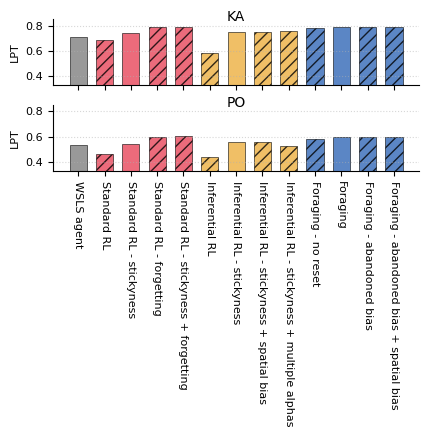

In [14]:
def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = 12, 5

    # Define the modes and figure
    modes = ['LPT_best']
    fig, ax = plt.subplots(1, 1, figsize=(w/2.54, h/2.54), gridspec_kw={'wspace': 0})

    # Iterate over the modes and plot
    for i, mode in enumerate(modes):        
        '''# Create a bar plot directly from the DataFrame
        # Create a bar plot with overlapping bars
        sns.barplot(
            data=res_all.loc[res_all['monkey'] != 'yu_DCZ'],
            x='Model',
            y=mode,
            hue='monkey',
            palette=COLORS,
            ax=ax,
            edgecolor='black',
            linewidth=0.5,
            legend=True,
            dodge=0.1  # Adjust this value to control overlap (0.5-0.8 typically works well)
        )'''
        # Get unique values
        models = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'Model'].unique()
        monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

        # Set up positions
        x = np.arange(len(models))
        width = 0.5  # Width of bars
        offset = 0.25  # How much to offset for overlap

        for i, monkey in enumerate(monkeys):
            data = res_all.loc[(res_all['monkey'] == monkey) & (res_all['monkey'] != 'yu_DCZ')]
            values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
            
            ax.bar(x + i*offset, values, width, 
                label=monkey, color=COLORS[monkey], 
                edgecolor='black', linewidth=0.5, alpha=0.8)
            
            for model, value in zip(models, values):
                print(f"{mode}: {monkey} {model}: {value:.2f}")

        # Configure axes
        ax.set_ylabel(mode)
        ax.set_xticks(x + offset/2)
        ax.set_xticklabels(models, rotation=45, horizontalalignment='right')

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        #ax.legend()
        
        # Set y-axis limits and labels based on the mode
        ax.set_ylim(0.33, 0.80)
        ax.set_yticks(np.arange(0.4, 0.9, 0.1))
        ax.set_ylabel('LPT', fontsize=8)
        #ax.legend(title='Monkey', fontsize=8, loc='upper left', bbox_to_anchor=(1, 1), frameon=True)

    return fig, ax

def plot_res(res_all, paper_format=False):
    # Set font size and figure size
    if paper_format:
        plt.rcParams.update({'font.size': 8})
        w, h = 4, 4
    else:
        plt.rcParams.update({'font.size': 8})
        w, h = 12, 5

    # Define the modes and figure
    modes = ['LPT_best']
    fig, axes = plt.subplots(2, 1, figsize=(w/2.54, h/2.54), gridspec_kw={'hspace': 0.3})

    # Get unique values
    models = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'Model'].unique()
    monkeys = res_all.loc[res_all['monkey'] != 'yu_DCZ', 'monkey'].unique()

    # Iterate over the modes and plot
    for mode_idx, mode in enumerate(modes):
        # Set up positions
        x = np.arange(len(models))
        width = 0.65  # Width of bars

        for i, monkey in enumerate(monkeys):
            ax = axes[i]  # Use separate subplot for each monkey
            
            data = res_all.loc[(res_all['monkey'] == monkey) & (res_all['monkey'] != 'yu_DCZ')]
            values = [data.loc[data['Model'] == model, mode].iloc[0] if len(data.loc[data['Model'] == model]) > 0 else 0 for model in models]
            
            # Create bars with model-based coloring
            for j, (model, value) in enumerate(zip(models, values)):
                hatch = None
                if model.split()[0] == 'Standard':
                    # replace  what comes after with RL
                    color = COLORS['Standard RL']
                    if not model == 'Standard RL - stickyness':
                        hatch = '///'  # Dashed filling pattern
                elif model.split()[0] == 'Inferential':
                    color = COLORS['Inferential RL']
                    if not model == 'Inferential RL - stickyness':
                        hatch = '///'  # Dashed filling pattern
                elif model.split()[0] == 'Foraging':
                    color = COLORS['Foraging']
                    if not len(model.split(" ")) == 1:
                        hatch = '///'  # Dashed filling pattern
                else:
                    color = COLORS.get(model, 'grey')
                    hatch = None
                alpha = 0.8
                
                
                bar = ax.bar(x[j], value, width, 
                    color=color, hatch=hatch,
                    edgecolor='black', linewidth=0.5, alpha=alpha)
                
                # Set hatch color to grey for RL-s models
                if model.split()[-1] == 'RL-s':
                    import matplotlib as mpl
                    mpl.rcParams['hatch.color'] = 'grey'
            
            
            for model, value in zip(models, values):
                print(f"{mode}: {monkey} {model}: {value:.2f}")

            # add monkey name (capitalized) as title, y axis a bit lower
            ax.set_title(monkey.upper(), fontsize=10, y=.85)

            # Configure axes
            ax.set_ylim(0.33, 0.85)
            ax.set_yticks(np.arange(0.4, 0.9, 0.2))
            ax.set_ylabel('LPT', fontsize=8)
            
            ax.spines['top'].set_visible(False)
            ax.spines['right'].set_visible(False)

            ax.grid(axis='y', linestyle='dotted', alpha=0.5, zorder=0)

            # Only add x-axis labels to bottom plot
            if i == len(monkeys) - 1:  # Bottom plot
                ax.set_xticks(x)
                ax.set_xticklabels(models, rotation=-90, horizontalalignment='center')
            else:  # Top plot
                ax.set_xticks(x)
                ax.set_xticklabels([])  # Remove x-axis labels from top plot

    return fig, axes

fig, ax = plot_res(res_all, paper_format=False)

# Adjust layout and save as SVG if needed
#plt.tight_layout()
# Uncomment the following line to save the figure
plt.savefig('figs/lpt.png', dpi=300, bbox_inches='tight', transparent=False)

plt.show()

In [15]:
b = 1000
diff = 1

1 / (1 + np.exp(b * (diff)))

/var/folders/sc/1kct8wp55hz13v5hhnxrrfy40000gn/T/ipykernel_23387/2354731913.py:4: RuntimeWarning: overflow encountered in exp
  1 / (1 + np.exp(b * (diff)))


0.0

In [16]:
text = ""

In [17]:
import re, sys
fname = 'bib.txt'
#fname = 'figs/lpt.png'
with open(fname, 'r') as f:
    text = f.read()
records = [r.strip() for r in re.split(r'\n\s*\n', text) if r.strip()]
deduped = sorted(set(records))  # sets remove duplicates; sort for stable output

# write back to file
with open(fname, 'w') as f:
    f.write('\n\n'.join(deduped))
    